<a href="https://colab.research.google.com/github/jiang-h-y/gait-condition-classification/blob/main/analysis_independent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo
!pip install tsfresh

In [71]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [38]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
multivariate_gait_data = fetch_ucirepo(id=760)

# store data as df
df = multivariate_gait_data.data.features

In [39]:
df

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
181795,10,3,10,2,3,96,29.778412
181796,10,3,10,2,3,97,29.247559
181797,10,3,10,2,3,98,28.796951
181798,10,3,10,2,3,99,28.432936


In [40]:
# add identifier columns
tsf_df = df.copy()
tsf_df["tsf_id"] = (
    df["subject"].astype(str) + "_" +
    df["replication"].astype(str) + "_" +
    df["condition"].astype(str) + "_" +
    df["leg"].astype(str) + "_" +
    df["joint"].astype(str)
)

### Independent leg and joint angles
*Instead of capturing angles for all leg and joint combinations, each observation only contains the angle of one leg and joint combination. This treats each of the leg/joint angles as independent, which is a simplifying assumption. This assumption allows for a larger dataset, which is a trade-off we wanted to explore.*

In [ ]:
# split training/testing data by subjects
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

train_tsf = tsf_df[tsf_df["subject"].isin(train_subjects)]
test_tsf = tsf_df[tsf_df["subject"].isin(test_subjects)]

# try extracting features, where leg_joint features are considered interdependent
# results in fewer rows of data
X_train_tsf1_long = train_tsf[["time", "angle", "tsf_id"]]
X_test_tsf1_long = test_tsf[["time", "angle", "tsf_id"]]

X_train_tsf1 = impute(extract_features(
    X_train_tsf1_long, column_id="tsf_id",column_sort="time", column_value="angle",
    default_fc_parameters=EfficientFCParameters()
    ))
X_test_tsf1 = impute(extract_features(
    X_test_tsf1_long, column_id="tsf_id", column_sort="time", column_value="angle",
    default_fc_parameters=EfficientFCParameters()
))

# identify labels
y_train_tsf1 = train_tsf.groupby("tsf_id")["condition"].first().reindex(X_train_tsf1.index)
y_test_tsf1 = test_tsf.groupby("tsf_id")["condition"].first().reindex(X_test_tsf1.index)

In [42]:
# filter for relevant features
X_train_tsf1 = select_features(X_train_tsf1, y_train_tsf1)
X_test_tsf1 = X_test_tsf1[X_train_tsf1.columns]

In [43]:
X_train_tsf1.shape

(1440, 367)

There data is extremely high-dimensional.

Here are a few ideas to address the curse of dimensionality:
1. PCA -> SVM: reduce dimensionality, then apply classifier
2. RF feature selection -> RF: select the most important features, then retrain

### SVM (with PCA for dimensionality reduction)

In [44]:
# scale the data
scaler = StandardScaler()
X_train_tsf1_scaled = scaler.fit_transform(X_train_tsf1)
X_test_tsf1_scaled = scaler.transform(X_test_tsf1)

Text(0.5, 1.0, 'Number of PCA Components vs. Explained Variance')

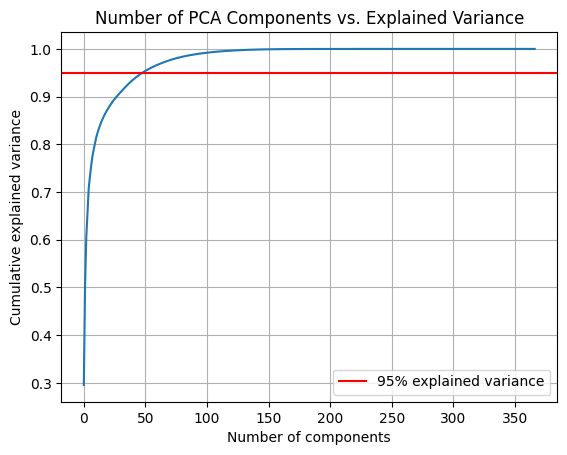

In [45]:
# plot a graph to figure out the optimal number of PCA components
pca = PCA().fit(X_train_tsf1_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="red", label="95% explained variance")
plt.legend()
plt.grid(True)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Number of PCA Components vs. Explained Variance")

In [46]:
# identify the specific number of components
opt_n = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95)
print(f"Optimal number of PCA components: {opt_n}")

Optimal number of PCA components: 48


In [47]:
# apply PCA
pca = PCA(n_components=opt_n)
X_train_pca = pca.fit_transform(X_train_tsf1_scaled)
X_test_pca = pca.transform(X_test_tsf1_scaled)

# # feed the data into an SVM
svm = SVC()
svm.fit(X_train_pca, y_train_tsf1)
predicted = svm.predict(X_test_pca)
print(classification_report(y_test_tsf1, predicted))

              precision    recall  f1-score   support

           1       0.66      0.33      0.44       120
           2       0.68      0.82      0.75       120
           3       0.56      0.72      0.63       120

    accuracy                           0.62       360
   macro avg       0.63      0.62      0.61       360
weighted avg       0.63      0.62      0.61       360



With the assumption of independent leg/joint angles, the model performs significantly worse.

### Random Forest

In [48]:
# train an initial RF
rf = RandomForestClassifier()
rf.fit(X_train_tsf1, y_train_tsf1)
predicted = rf.predict(X_test_tsf1)
print(classification_report(y_test_tsf1, predicted))

# extract feature importances
importances = rf.feature_importances_
feature_names = X_train_tsf1.columns
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})

# rank features by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

              precision    recall  f1-score   support

           1       0.61      0.34      0.44       120
           2       0.65      0.77      0.70       120
           3       0.56      0.70      0.62       120

    accuracy                           0.60       360
   macro avg       0.61      0.60      0.59       360
weighted avg       0.61      0.60      0.59       360



In [49]:
feature_importances.head()

,feature,importance
4,angle__partial_autocorrelation__lag_1,0.019065
5,angle__autocorrelation__lag_1,0.016364
2,"angle__agg_linear_trend__attr_""stderr""__chunk_...",0.011669
322,"angle__linear_trend__attr_""intercept""",0.010938
24,angle__autocorrelation__lag_2,0.010433


In [50]:
feature_importances.tail()

,feature,importance
261,angle__symmetry_looking__r_0.05,0.000070
243,angle__number_crossing_m__m_-1,0.000066
223,angle__symmetry_looking__r_0.15000000000000002,0.000044
283,angle__symmetry_looking__r_0.1,0.000010
62,"angle__fft_coefficient__attr_""angle""__coeff_0",0.000000


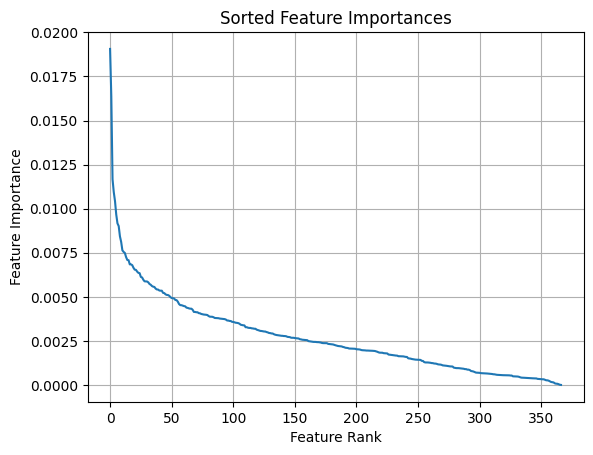

In [51]:
plt.plot(range(len(feature_importances)), feature_importances["importance"])
plt.xlabel("Feature Rank")
plt.ylabel("Feature Importance")
plt.title("Sorted Feature Importances")
plt.grid(True)
plt.show()

None of the features have extremely high importance, but the feature importance does seem to diminish around 25-50 features.

In [67]:
# try different numbers of features
for n in [10, 25, 50, 100]:
  rf = RandomForestClassifier()
  subset = feature_importances["feature"][:n]
  rf.fit(X_train_tsf1[subset], y_train_tsf1)
  accuracy = rf.score(X_test_tsf1[subset], y_test_tsf1)
  print(f"Accuracy with {n} features: {accuracy:.4f}")

Accuracy with 10 features: 0.5000
Accuracy with 25 features: 0.5194
Accuracy with 50 features: 0.5833
Accuracy with 100 features: 0.5778


The number of features that produces the highest accuracy varies depending on `random_state`. However, based on both the plot and the accuracy metrics above, 50 features seems like a reasonable number.

In [78]:
# filter for the top 50 features
X_train_filtered = X_train_tsf1[feature_importances["feature"][:50]]
X_test_filtered = X_test_tsf1[feature_importances["feature"][:50]]

In [79]:
# test out different hyperparams
params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

random_search = RandomizedSearchCV(RandomForestClassifier(), params)
random_search.fit(X_train_filtered, y_train_tsf1)

print("Best Estimator:", random_search.best_estimator_)

Best Estimator: RandomForestClassifier(min_samples_leaf=2, n_estimators=200)


In [80]:
# train the Random Forest based on filtered features and tuned hyperparams
rf = random_search.best_estimator_
rf.fit(X_train_filtered, y_train_tsf1)
predicted = rf.predict(X_test_filtered)
print(classification_report(y_test_tsf1, predicted))


              precision    recall  f1-score   support

           1       0.61      0.30      0.40       120
           2       0.61      0.66      0.63       120
           3       0.54      0.78      0.64       120

    accuracy                           0.58       360
   macro avg       0.59      0.58      0.56       360
weighted avg       0.59      0.58      0.56       360



Feature selection and hyperparameter tuning did not improve the model, and many of the metrics actually worsened.

Based on these results, we concluded that this is not the best way to represent the data. Interdependent leg/joint relationships are important to classifying the data.